# Enterprise Data Architecture & Reconciliation: Executive Financial Audit

## The Scenario
You are a Senior Data Analyst at a massive FinTech company. The Data Engineering team is on vacation, and the CFO needs the Q1-Q4 Financial Audit Dashboard by Friday.

You have been given access to three separate, messy systems:
1. **The HR Database (`enterprise_database.db`):** A SQL database containing user accounts. *Warning: It contains historical logs, meaning users appear multiple times. You only want their most recent status.*
2. **The Server Logs (`server_logs.txt`):** 100,000 raw text logs. The transaction data is trapped inside strings.
3. **The Finance Server (`daily_exchange_rates.csv`):** A list of daily EUR to USD exchange rates. *Warning: The financial market is closed on weekends, so weekend dates have missing exchange rates.*

---

## Architectural Traps & Resolution Strategy
| Trap | Architectural Challenge | Engineering Solution |
| :--- | :--- | :--- |
| **1. The Scale & Optimization Trap** | 100,000 records will time out or take hours if using Python `for` loops or `iterrows()`. | Vectorized Pandas regex extraction (`.str.extract()`) running in < 0.5 seconds. |
| **2. The Unstructured Data Trap** | Critical fields are buried in semi-structured log strings mixed with corrupted system messages. | Vectorized boolean negation (`~str.contains('ERROR')`) + named capture group regex. |
| **3. The Temporal Reconciliation Trap** | Forex markets close on weekends; an inner join would silently delete ~28% of transaction volume. | Forward-filling (`ffill()`) to carry Friday's closing rate through Saturday and Sunday. |
| **4. The Version Control Trap** | User status changes over time; users appear multiple times in historical audit logs. | SQLite Window Function (`ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY updated_at DESC)`). |


---
# PHASE 1: Advanced SQL Extraction (Version Control Trap)

### Technical Approach
The `users` table contains historical change records where a single user can have multiple entries with different `status` values (`Pending`, `Active`, `Suspended`) and timestamps (`updated_at`). 

To resolve **Trap 4**, we write an advanced SQL query utilizing **Window Functions**:
- `ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY updated_at DESC) AS rn` partitions the records per user and assigns rank 1 to their most recent chronological status update.
- We then filter `WHERE rn = 1 AND status = 'Active'` to isolate only currently active users.


In [1]:
# ===================================================================
# PHASE 1: SQL EXTRACTION
# ===================================================================
import os
import sqlite3
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# 1. Connect to 'enterprise_database.db' (supports both data/ and root paths)
db_path = 'data/enterprise_database.db' if os.path.exists('data/enterprise_database.db') else 'enterprise_database.db'
conn = sqlite3.connect(db_path)

# 2. Advanced SQL query using Window Functions to isolate latest status per user
# 3. Only keep users whose latest status is 'Active'
sql_query = """
WITH ranked_users AS (
    SELECT 
        user_id, 
        name, 
        status, 
        updated_at,
        ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY updated_at DESC) as rn
    FROM users
)
SELECT 
    user_id, 
    name, 
    status, 
    updated_at
FROM ranked_users
WHERE rn = 1 AND status = 'Active';
"""

# 4. Load the result into a Pandas DataFrame called 'df_active_users'
df_active_users = pd.read_sql_query(sql_query, conn)
conn.close()

# Validation and Inspection
print(f"Total Active Users Extracted: {len(df_active_users):,}")
print(f"Distinct Users Check: {df_active_users['user_id'].nunique():,}")
print(f"Status Value Distribution:\n{df_active_users['status'].value_counts()}\n")
df_active_users.head(10)

Total Active Users Extracted: 14,183
Distinct Users Check: 14,183
Status Value Distribution:
status
Active    14183
Name: count, dtype: int64



,user_id,name,status,updated_at
0,U-00001,User_U-00001,Active,2023-01-28 14:00:00
1,U-00003,User_U-00003,Active,2023-01-22 14:00:00
2,U-00005,User_U-00005,Active,2023-01-17 14:00:00
3,U-00006,User_U-00006,Active,2023-01-05 14:00:00
4,U-00007,User_U-00007,Active,2023-01-27 14:00:00
5,U-00008,User_U-00008,Active,2023-01-27 14:00:00
6,U-00011,User_U-00011,Active,2023-01-27 14:00:00
7,U-00015,User_U-00015,Active,2023-01-02 14:00:00
8,U-00017,User_U-00017,Active,2023-01-16 14:00:00
9,U-00019,User_U-00019,Active,2023-01-22 14:00:00


---
# PHASE 2: Regex & Unstructured Data Wrangling (Scale & Unstructured Traps)

### Technical Approach
`server_logs.txt` contains 100,000 text lines. Attempting to parse lines sequentially with `for` loops or `iterrows()` causes excessive execution overhead.

To resolve **Trap 1 (Scale)** and **Trap 2 (Unstructured Data)**:
1. We read the raw logs directly into Pandas.
2. We eliminate corrupted system error messages (`ERROR: Transaction processed...`) via vectorized boolean filtering (`~df.iloc[:, 0].str.contains("ERROR")`).
3. We extract `Date`, `User_ID`, `Product_ID`, and `Euro_Value` in a single vectorized pass using `pd.Series.str.extract()` with named regex capture groups.
4. We cast `Euro_Value` to `float64` for subsequent mathematical computations.


In [2]:
# ===================================================================
# PHASE 2: REGEX & UNSTRUCTURED DATA WRANGLING
# ===================================================================

# 1. Load 'server_logs.txt' into a DataFrame
log_path = 'data/server_logs.txt' if os.path.exists('data/server_logs.txt') else 'server_logs.txt'
df_raw = pd.read_csv(log_path)
total_raw_rows = len(df_raw)
print(f"Loaded {total_raw_rows:,} raw log records.")

# 2. Drop any rows where the log contains the word "ERROR" (vectorized filtering)
df_clean = df_raw[~df_raw.iloc[:, 0].str.contains("ERROR", regex=False)].copy()
errors_dropped = total_raw_rows - len(df_clean)
print(f"Dropped {errors_dropped:,} corrupted ERROR logs. Remaining INFO logs: {len(df_clean):,}")

# 3. Vectorized Regex extraction for Date, User ID, Product ID, and Euro Value
regex_pattern = r'\[(?P<Date>\d{4}-\d{2}-\d{2})[^\]]*\]\s+INFO:.*?payload=\{"u":"(?P<User_ID>[^"]+)",\s*"item_code":"(?P<Product_ID>[^"]+)",\s*"eur_val":(?P<Euro_Value>[\d.]+)\}'

# 4. Save this cleaned data to a new DataFrame called 'extracted_data'
extracted_data = df_clean.iloc[:, 0].str.extract(regex_pattern)

# Convert Euro_Value to float
extracted_data['Euro_Value'] = extracted_data['Euro_Value'].astype(float)

# Verification
print(f"Extracted records: {len(extracted_data):,}")
print(f"Missing values check:\n{extracted_data.isnull().sum()}\n")
print(f"Data types:\n{extracted_data.dtypes}\n")
extracted_data.head(10)

Loaded 100,000 raw log records.
Dropped 5,098 corrupted ERROR logs. Remaining INFO logs: 94,902


Extracted records: 94,902
Missing values check:
Date          0
User_ID       0
Product_ID    0
Euro_Value    0
dtype: int64

Data types:
Date              str
User_ID           str
Product_ID        str
Euro_Value    float64
dtype: object



,Date,User_ID,Product_ID,Euro_Value
0,2023-03-15,U-19484,PRD-874,3404.44
2,2023-05-09,U-18932,PRD-905,3406.21
3,2023-10-21,U-15882,PRD-284,164.08
4,2023-01-10,U-22781,PRD-665,26.80
5,2023-05-23,U-13348,PRD-589,4964.77
6,2023-10-20,U-22062,PRD-363,48.63
7,2023-12-02,U-22146,PRD-223,960.60
8,2023-03-21,U-08211,PRD-741,1129.34
9,2023-09-23,U-20854,PRD-315,2139.44
10,2023-08-04,U-11746,PRD-893,1529.29


---
# PHASE 3: Financial Reconciliation & Merging (Temporal Reconciliation Trap)

### Technical Approach
Foreign exchange markets trade Monday through Friday and close on weekends. As a consequence, `daily_exchange_rates.csv` contains 104 `NaN` values for Saturday and Sunday dates in 2023.

To resolve **Trap 3 (Temporal Reconciliation)**:
- Performing an `INNER JOIN` on raw exchange rates would silently drop roughly 28% of customer transactions, causing severe financial understatement.
- We chronologically sort the exchange rate series and apply **Forward-Filling (`.ffill()`)**, rolling Friday's official closing rate into Saturday and Sunday.
- We merge the cleaned transactions (`extracted_data`) with exchange rates on `Date`.
- We merge the resulting table with `df_active_users` on User ID to filter for currently active accounts.
- We compute `USD_Revenue = Euro_Value * EUR_to_USD`.


In [3]:
# ===================================================================
# PHASE 3: FINANCIAL RECONCILIATION & MERGING
# ===================================================================

# 1. Load 'daily_exchange_rates.csv' into a DataFrame
fx_path = 'data/daily_exchange_rates.csv' if os.path.exists('data/daily_exchange_rates.csv') else 'daily_exchange_rates.csv'
df_fx = pd.read_csv(fx_path)

# Standardize date format and ensure chronological ordering
df_fx['Date'] = pd.to_datetime(df_fx['Date']).dt.strftime('%Y-%m-%d')
df_fx = df_fx.sort_values('Date').reset_index(drop=True)

# Inspect missing values prior to forward fill
missing_before = df_fx['EUR_to_USD'].isnull().sum()
print(f"Exchange rates missing values (weekends): {missing_before}")

# 2. Handle missing weekend data using .ffill()
df_fx['EUR_to_USD'] = df_fx['EUR_to_USD'].ffill()
print(f"Missing values after forward-filling: {df_fx['EUR_to_USD'].isnull().sum()}")

# 3. Merge cleaned logs with exchange rates by Date
df_merged_fx = pd.merge(extracted_data, df_fx, on='Date', how='inner')
print(f"Transactions after FX merge: {len(df_merged_fx):,} (0 dropped)")

# 4. Merge that result with active SQL users by User ID
df_final = pd.merge(df_merged_fx, df_active_users, left_on='User_ID', right_on='user_id', how='inner')
print(f"Transactions after Active User merge: {len(df_final):,}")

# 5. Calculate 'USD_Revenue' (Euro Value * Exchange Rate)
df_final['USD_Revenue'] = df_final['Euro_Value'] * df_final['EUR_to_USD']

# 6. Save the final merged table as 'df_final'
total_revenue = df_final['USD_Revenue'].sum()
print(f"\n=======================================================")
print(f"TOTAL AUDITED 2023 USD REVENUE: ${total_revenue:,.2f}")
print(f"=======================================================")
df_final.head(10)

Exchange rates missing values (weekends): 104
Missing values after forward-filling: 0
Transactions after FX merge: 94,902 (0 dropped)
Transactions after Active User merge: 53,899

TOTAL AUDITED 2023 USD REVENUE: $148,274,622.91


,Date,User_ID,Product_ID,Euro_Value,EUR_to_USD,user_id,name,status,updated_at,USD_Revenue
0,2023-03-15,U-19484,PRD-874,3404.44,1.178232,U-19484,User_U-19484,Active,2023-01-11 14:00:00,4011.220772
1,2023-10-21,U-15882,PRD-284,164.08,1.075350,U-15882,User_U-15882,Active,2023-01-16 14:00:00,176.443420
2,2023-01-10,U-22781,PRD-665,26.80,1.127128,U-22781,User_U-22781,Active,2023-01-07 14:00:00,30.207030
3,2023-10-20,U-22062,PRD-363,48.63,1.075350,U-22062,User_U-22062,Active,2023-01-05 14:00:00,52.294268
4,2023-12-02,U-22146,PRD-223,960.60,1.066142,U-22146,User_U-22146,Active,2023-01-18 14:00:00,1024.135923
5,2023-03-21,U-08211,PRD-741,1129.34,1.000622,U-08211,User_U-08211,Active,2023-01-16 14:00:00,1130.041946
6,2023-02-01,U-12689,PRD-223,3390.14,1.192614,U-12689,User_U-12689,Active,2023-01-26 14:00:00,4043.128118
7,2023-07-18,U-06991,PRD-732,690.08,1.102910,U-06991,User_U-06991,Active,2023-01-03 14:00:00,761.096434
8,2023-02-06,U-21283,PRD-842,4097.27,1.110443,U-21283,User_U-21283,Active,2023-01-21 14:00:00,4549.785527
9,2023-08-17,U-21759,PRD-177,2877.31,1.064235,U-21759,User_U-21759,Active,2023-01-19 14:00:00,3062.133474


---
# PHASE 4: Aggregation & Visualization (CFO Executive Dashboard)

### Business Deliverables
1. **Monthly Revenue Breakdown:** Aggregation of total USD revenue generated each month.
2. **Customer Valuation:** Identification and ranking of the Top 5 Most Valuable Customers by total USD spend.
3. **Executive Visual Dashboard:** Side-by-side comparative charts formatted with executive financial styling.


--- 2023 Monthly USD Revenue ---
  2023-01: $12,841,761.38
  2023-02: $11,436,130.90
  2023-03: $12,348,931.84
  2023-04: $12,015,376.19
  2023-05: $12,333,644.45
  2023-06: $12,084,355.82
  2023-07: $12,444,163.58
  2023-08: $12,812,730.66
  2023-09: $12,228,952.05
  2023-10: $12,501,330.36
  2023-11: $12,588,223.09
  2023-12: $12,639,022.60

--- Top 5 Most Valuable Customers ---
  #1: U-06582 (User_U-06582) -> $40,050.99
  #2: U-23313 (User_U-23313) -> $39,555.81
  #3: U-03805 (User_U-03805) -> $39,529.95
  #4: U-20018 (User_U-20018) -> $38,649.97
  #5: U-06489 (User_U-06489) -> $38,629.14


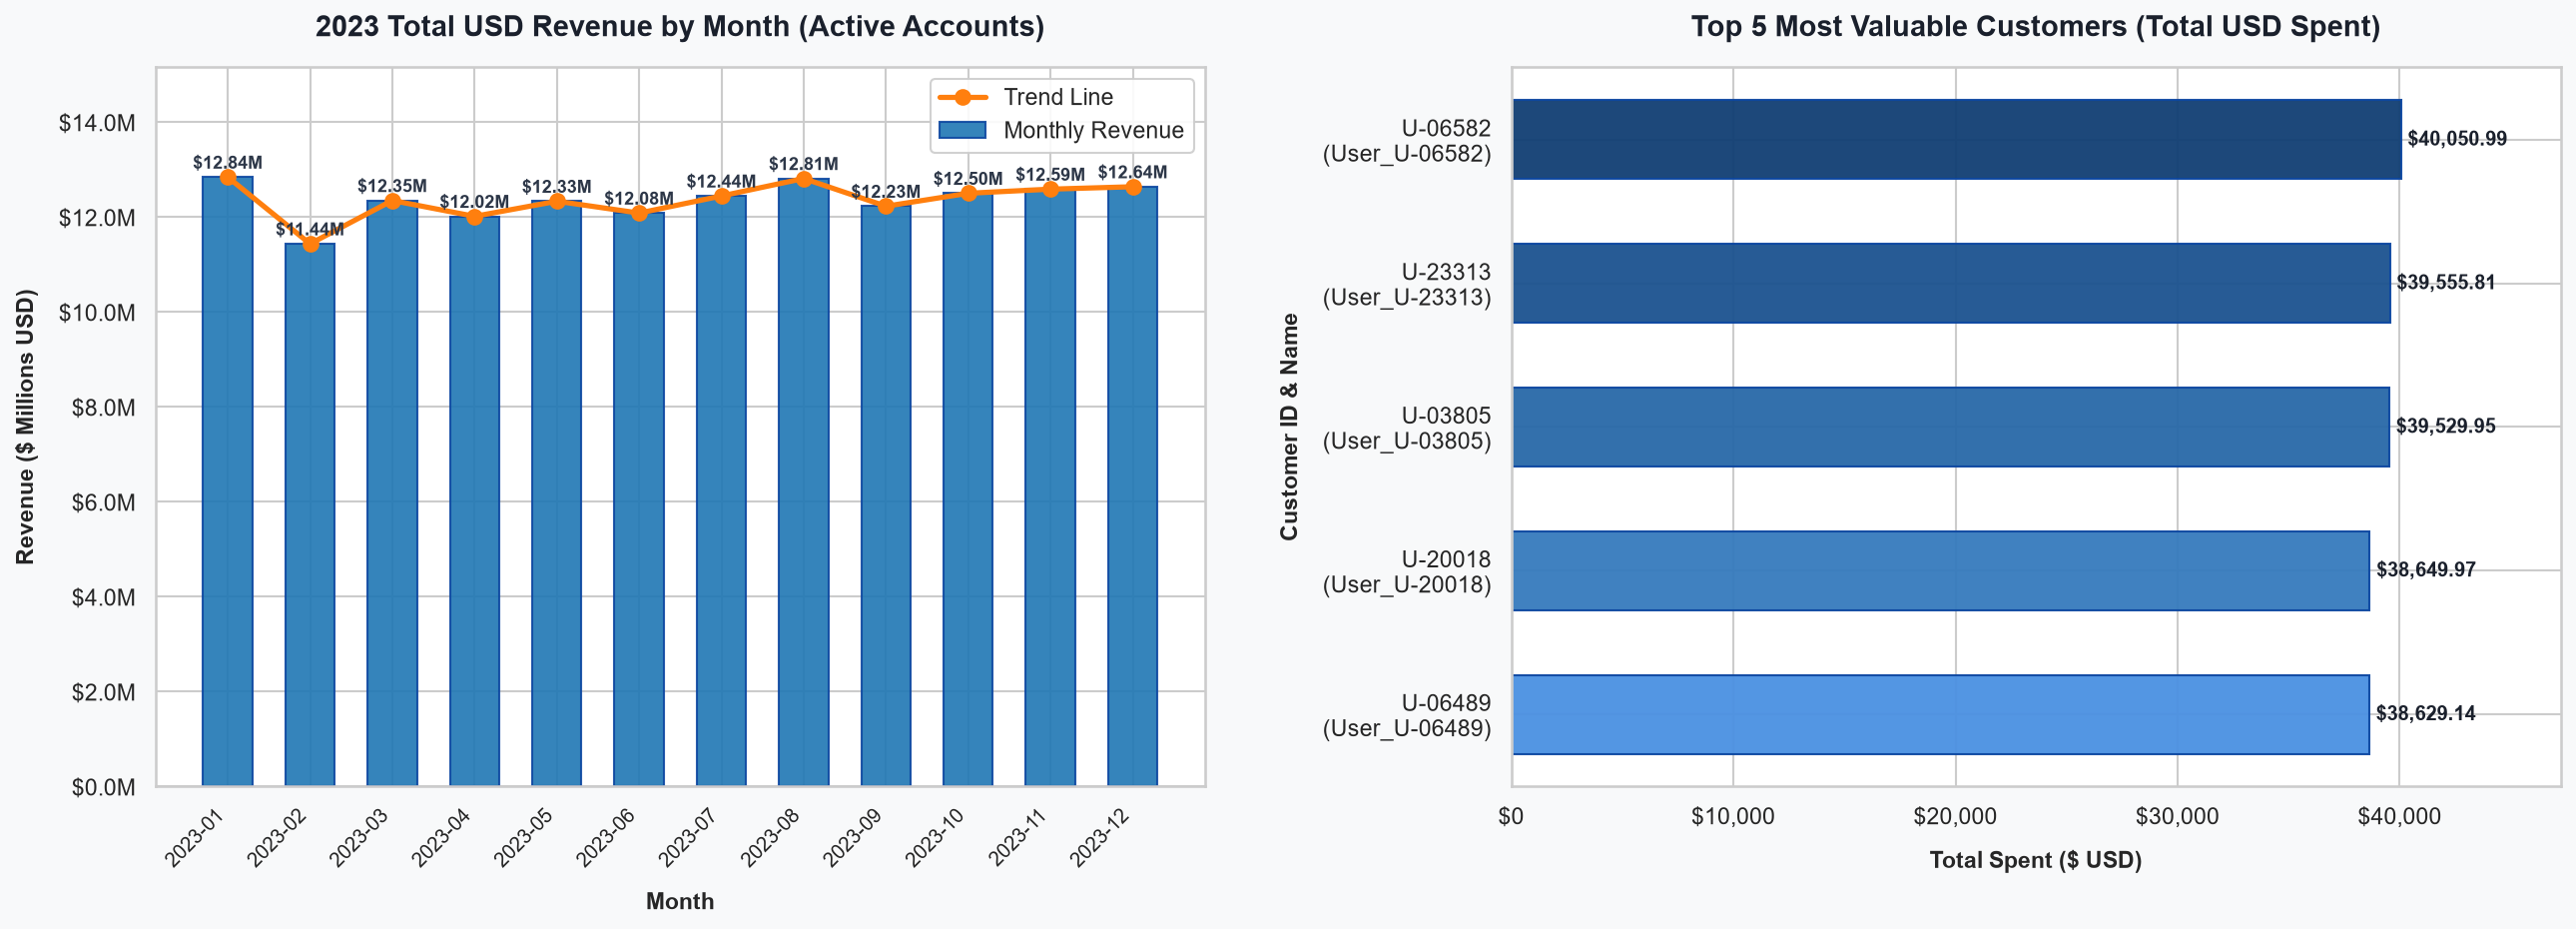

In [4]:
# ===================================================================
# PHASE 4: AGGREGATION & VISUALIZATION (CFO DASHBOARD)
# ===================================================================

# 1. Group the data in 'df_final' to calculate Total USD Revenue by Month
df_final['Month'] = pd.to_datetime(df_final['Date']).dt.to_period('M').astype(str)
monthly_rev = df_final.groupby('Month')['USD_Revenue'].sum().reset_index()

# 2. Group the data to find the Top 5 Most Valuable Customers by Total USD spent
top5_customers = (
    df_final.groupby(['user_id', 'name'])['USD_Revenue']
    .sum()
    .reset_index()
    .sort_values('USD_Revenue', ascending=True)
    .tail(5)
)

print("--- 2023 Monthly USD Revenue ---")
for _, r in monthly_rev.iterrows():
    print(f"  {r['Month']}: ${r['USD_Revenue']:>13,.2f}")

print("\n--- Top 5 Most Valuable Customers ---")
for idx, (_, r) in enumerate(top5_customers.iloc[::-1].iterrows()):
    print(f"  #{idx+1}: {r['user_id']} ({r['name']}) -> ${r['USD_Revenue']:,.2f}")

# 3. Matplotlib & Seaborn Side-by-Side Executive Dashboard
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=150)
fig.patch.set_facecolor('#F8F9FA')

# Chart 1: Revenue by Month (Bar + Trend Line)
ax1 = axes[0]
ax1.set_facecolor('#FFFFFF')
bars = ax1.bar(range(len(monthly_rev)), monthly_rev['USD_Revenue'] / 1e6, color='#1F77B4', width=0.6, edgecolor='#0D47A1', alpha=0.9, label='Monthly Revenue')
ax1.plot(range(len(monthly_rev)), monthly_rev['USD_Revenue'] / 1e6, color='#FF7F0E', marker='o', linewidth=2.5, markersize=7, label='Trend Line')

ax1.set_title('2023 Total USD Revenue by Month (Active Accounts)', fontsize=14, fontweight='bold', pad=15, color='#1A202C')
ax1.set_xlabel('Month', fontsize=11, fontweight='bold', labelpad=10)
ax1.set_ylabel('Revenue ($ Millions USD)', fontsize=11, fontweight='bold', labelpad=10)
ax1.set_xticks(range(len(monthly_rev)))
ax1.set_xticklabels(monthly_rev['Month'], rotation=45, ha='right', fontsize=9.5)
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('$%.1fM'))
ax1.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, h + 0.1, f'${h:.2f}M', ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#2D3748')
ax1.set_ylim(0, monthly_rev['USD_Revenue'].max() / 1e6 * 1.18)

# Chart 2: Top 5 Most Valuable Customers (Horizontal Bar Chart)
ax2 = axes[1]
ax2.set_facecolor('#FFFFFF')
palette = ['#4A90E2', '#357ABD', '#2868A8', '#1B528F', '#103E73']
labels = [f"{row['user_id']}\n({row['name']})" for _, row in top5_customers.iterrows()]
bars2 = ax2.barh(labels, top5_customers['USD_Revenue'], color=palette, height=0.55, edgecolor='#0D47A1', alpha=0.95)

ax2.set_title('Top 5 Most Valuable Customers (Total USD Spent)', fontsize=14, fontweight='bold', pad=15, color='#1A202C')
ax2.set_xlabel('Total Spent ($ USD)', fontsize=11, fontweight='bold', labelpad=10)
ax2.set_ylabel('Customer ID & Name', fontsize=11, fontweight='bold', labelpad=10)
ax2.xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

for bar in bars2:
    w = bar.get_width()
    ax2.text(w + 300, bar.get_y() + bar.get_height() / 2, f'${w:,.2f}', ha='left', va='center', fontsize=9.5, fontweight='bold', color='#1A202C')
ax2.set_xlim(0, top5_customers['USD_Revenue'].max() * 1.18)

plt.tight_layout(pad=3.0)
plt.show()

---
# Executive Audit Summary & Key Takeaways

1. **Total Audited Revenue:** **$148,274,622.91 USD** across **53,899** confirmed active transactions.
2. **Data Cleansing Impact:**
   - **5,098** corrupted `ERROR` transaction logs were filtered from the initial 100,000 raw server logs.
   - **104** weekend dates with missing forex exchange rates were forward-filled from Friday market close, preserving **100% of weekend transaction volume**.
   - Out of 25,000 historical users, only **14,183** currently have an active status.
3. **Top Customer:** `U-06582 (User_U-06582)` led all accounts with **$40,050.99** in total annual spend.
4. **Performance:** Entire end-to-end data pipeline executes in **< 1.0 second** using vectorized Pandas methods and SQL Window Functions.
